# Exoplanet Habitability — Unsupervised Exploration

We explore 6150 confirmed exoplanets from the NASA Exoplanet Archive
and try to identify potentially habitable candidates without any labels.

Our anchor : Earth. If our clustering puts Earth in the right group, we're on track.
Validation : we compare our results against the Habitable Exoplanets Catalog (HEC).

In [ ]:
import requests
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np

In [2]:
# Création du dossier si besoin
raw_dir = Path("data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

output_file = raw_dir / "nasa_exoplanets.csv"

# Téléchargement depuis la NASA Exoplanet Archive
url = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+*+from+pscomppars"
    "&format=csv"
)

if output_file.exists():
    print("File already downloaded, loading from disk.")
else:
    print("Downloading data from NASA Exoplanet Archive...")
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    output_file.write_bytes(response.content)
    print("Download complete.")

# Chargement
df = pd.read_csv(output_file, comment="#", low_memory=False)
print(f"Dataset loaded: {df.shape[0]} planets, {df.shape[1]} features")

File already downloaded, loading from disk.
Dataset loaded: 6150 planets, 683 features


In [3]:
df.head(5)

,objectid,pl_name,pl_letter,hostid,hostname,hd_name,hip_name,tic_id,disc_pubdate,disc_year,...,cb_flag,pl_angsep,pl_angseperr1,pl_angseperr2,pl_angseplim,pl_angsepformat,pl_angsepstr,pl_angsepsymerr,pl_angsep_reflink,pl_ndispec
0,3.2390,Kepler-1167 b,b,2.136990,Kepler-1167,NaN,NaN,TIC 273875149,2016-05,2016.0,...,0,0.0213,NaN,NaN,0.0,NaN,0.0213,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0
1,3.1444,Kepler-1740 b,b,2.433343,Kepler-1740,NaN,NaN,TIC 138479461,2022-02,2021.0,...,0,0.0734,NaN,NaN,0.0,NaN,0.0734,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0
2,3.4135,Kepler-1581 b,b,2.442550,Kepler-1581,NaN,NaN,TIC 121215710,2016-05,2016.0,...,0,0.1390,NaN,NaN,0.0,NaN,0.1390,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0
3,3.6590,Kepler-644 b,b,2.512738,Kepler-644,NaN,NaN,TIC 271669616,2016-05,2016.0,...,0,0.0352,NaN,NaN,0.0,NaN,0.0352,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0
4,3.1575,Kepler-1752 b,b,2.507010,Kepler-1752,NaN,NaN,TIC 417655835,2022-02,2021.0,...,0,0.2800,NaN,NaN,0.0,NaN,0.2800,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0


In [4]:
# Types et valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
pl_angsepsymerr,6150,100.0
sy_hmagformat,6150,100.0
sy_jmagformat,6150,100.0
sy_plxformat,6150,100.0
sy_vmagformat,6150,100.0
...,...,...
st_mass_reflink,8,0.1
st_masslim,8,0.1
st_mass_solnid,8,0.1
st_massstr,8,0.1


In [5]:
# Colonnes qui ont moins de 30% de valeurs manquantes
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
usable_columns = missing_pct[missing_pct < 30].sort_values()

print(f"Usable columns (< 30% missing): {len(usable_columns)}")
print(usable_columns)

Usable columns (< 30% missing): 373
glon_solnid         0.0
sy_kmag_solnid      0.0
glon_reflink        0.0
htm20               0.0
z                   0.0
                   ... 
pl_impparerr2      29.9
pl_insol_solnid    29.9
pl_insol           29.9
pl_insollim        29.9
pl_insolstr        29.9
Length: 373, dtype: float64


In [6]:
# On liste juste les noms de colonnes, sans les metadata/reflink
core_columns = [col for col in usable_columns.index 
                if not any(col.endswith(s) for s in ["_reflink", "_solnid", "_str", "_lim", "err1", "err2"])]

print(f"Core columns: {len(core_columns)}")
for col in core_columns:
    print(col)

Core columns: 208
htm20
z
y
x
cb_flag
glat
glatstr
pl_name
elatstr
elat
elonstr
elon
sy_name
pl_controv_flag
rastr
dec
rv_flag
ast_flag
obm_flag
tran_flag
etv_flag
objectid
glonstr
pl_ndispec
rasymerr
pl_letter
hostname
disc_pubdate
hostid
disc_telescope
disc_instrument
disc_facility
disc_locale
discoverymethod
ra
disc_refname
disc_year
disc_method
glon
decsymerr
decstr
systemid
ttv_flag
ptv_flag
pl_nnotes
pl_ntranspec
pl_nespec
st_nrvc
st_nspec
disc_refid
dkin_flag
pl_bmassprov
micro_flag
st_nphot
sy_snum
sy_pnum
sy_mnum
pul_flag
ima_flag
st_mass
st_masslim
st_massstr
sy_distsymerr
sy_distlim
sy_diststr
sy_dist
pl_bmassjstr
pl_bmassj
pl_bmassjlim
pl_bmasse
pl_bmassestr
pl_bmasselim
pl_radjstr
pl_radelim
pl_radj
pl_radjlim
pl_rade
pl_radestr
pl_densstr
pl_dens
pl_denslim
sy_kmagstr
sy_kmagsymerr
sy_kmaglim
sy_kmag
tic_id
st_teffstr
st_teff
st_tefflim
sy_tmagstr
sy_hmaglim
sy_hmagstr
sy_tmag
sy_tmagsymerr
sy_hmag
sy_hmagsymerr
sy_vmaglim
sy_vmag
sy_vmagsymerr
sy_vmagstr
sy_jmag
sy_jmagl

# Exoplanet Habitability Classifier

## What we're doing

We want to classify exoplanets as potentially habitable or not, using data from the NASA Exoplanet Archive (6150 planets, 683 features).

We are building this project without a deep knowledge about astronomy, simply iterating through data and asking ourselves questions. 

---

## What "habitable" means for us

We focus on **Earth-like conditions** as a proxy for habitability :
- Right temperature range (liquid water possible)
- Similar size and mass to Earth
- Reasonable atmosphere (surface gravity)
- Stable orbit around its star

We don't have a ready-made `is_habitable` label in the dataset, so we'll build it ourselves from physical features.
And maybe compare later with real NASA predictions to test the accuracy of our model and predictions. 

---

## What we've done so far

**1. Data ingestion**
Downloaded the full Planetary Systems Composite Parameters table from NASA Exoplanet Archive via TAP query. 6150 planets, 683 features.

**2. Feature reduction — step 1 : remove sparse columns**
We dropped every column with more than 30% missing values. Arbitrary threshold, meaning 373 columns remaining.

**3. Feature reduction — step 2 : remove metadata columns**
Columns ending in `_reflink`, `_solnid`, `_str`, `_lim`, `err1`, `err2` are bibliographic references, not physical data. We removed them mechanically. 208 columns remaining.

**4. Feature reduction — step 3 : keep only physical columns**
We kept only columns starting with `pl_` (planet), `st_` (star), or `sy_` (system). Coordinates, detection flags, and identifiers are not relevant to habitability. This is again an arbitrary, in order to proceed with the project.

---

## Next steps

- Read the remaining physical columns and understand what each one measures
- Build our habitability label from physical criteria

In [7]:
# Keep only physical columns describing the planet, its star and its system
physical_columns = [col for col in core_columns
                    if col.startswith(("pl_", "st_", "sy_"))]

df_physical = df[physical_columns].copy()
print(f"Dataset shape: {df_physical.shape[0]} planets, {df_physical.shape[1]} features")
df_physical.head(3)

Dataset shape: 6150 planets, 161 features


,pl_name,sy_name,pl_controv_flag,pl_ndispec,pl_letter,pl_nnotes,pl_ntranspec,pl_nespec,st_nrvc,st_nspec,...,pl_impparlim,pl_trandeplim,pl_trandepstr,pl_imppar,pl_ratdorlim,pl_ratdor,pl_ratdorstr,pl_insol,pl_insollim,pl_insolstr
0,Kepler-1167 b,Kepler-1167,0,0,b,1,0,0,0,0,...,0.0,0.0,0.04911&plusmn0.00238,0.023,0.0,5.477,5.477&plusmn;0.315,1039.697,0.0,"<div><span class=supersubNumber"">1039.697</spa..."
1,Kepler-1740 b,Kepler-1740,0,0,b,0,0,0,0,0,...,0.0,0.0,"<div><span class=supersubNumber"">0.08643</span...",0.942,0.0,6.960,6.96&plusmn;0.6,127.950,0.0,"<div><span class=supersubNumber"">127.95</span>..."
2,Kepler-1581 b,Kepler-1581,0,0,b,1,0,0,0,0,...,0.0,0.0,0.00357&plusmn0.00026,0.101,0.0,11.490,11.49&plusmn;1.5,470.862,0.0,"<div><span class=supersubNumber"">470.862</span..."


In [8]:
# 1. Remove columns with HTML content
html_columns = [col for col in df_physical.columns
                if df_physical[col].astype(str).str.contains("<", na=False).any()]

# 2. Remove constant columns (zero variance)
constant_columns = [col for col in df_physical.columns
                    if df_physical[col].nunique() <= 1]

# 3. Remove metadata columns we missed (_lim, _str, _prov, flags, counts)
metadata_columns = [col for col in df_physical.columns
                    if any(col.endswith(s) for s in ["lim", "str", "prov"])
                    or col in ["pl_controv_flag", "pl_letter", "pl_nnotes",
                               "pl_ndispec", "pl_ntranspec", "pl_nespec",
                               "st_nrvc", "st_nspec", "st_nphot", "sy_mnum"]]

cols_to_drop = set(html_columns + constant_columns + metadata_columns)
df_clean = df_physical.drop(columns=cols_to_drop)

print(f"Dropped HTML columns     : {len(html_columns)}")
print(f"Dropped constant columns : {len(constant_columns)}")
print(f"Dropped metadata columns : {len(metadata_columns)}")
print(f"Remaining features       : {df_clean.shape[1]}")

Dropped HTML columns     : 31
Dropped constant columns : 13
Dropped metadata columns : 85
Remaining features       : 75


In [9]:
for col in df_clean.columns:
    missing = df_clean[col].isnull().mean() * 100
    print(f"{col:<30} {missing:.1f}% missing")

pl_name                        0.0% missing
sy_name                        0.0% missing
sy_snum                        0.0% missing
sy_pnum                        0.0% missing
st_mass                        0.1% missing
sy_distsymerr                  0.4% missing
sy_dist                        0.4% missing
pl_bmassj                      0.5% missing
pl_bmasse                      0.5% missing
pl_radj                        0.8% missing
pl_rade                        0.8% missing
pl_dens                        2.3% missing
sy_kmagsymerr                  4.6% missing
sy_kmag                        4.6% missing
st_teff                        4.7% missing
sy_tmag                        4.7% missing
sy_tmagsymerr                  4.7% missing
sy_hmag                        4.7% missing
sy_hmagsymerr                  4.7% missing
sy_vmag                        4.8% missing
sy_vmagsymerr                  4.8% missing
sy_jmag                        4.9% missing
sy_pmra                        4

In [10]:
# Drop error columns and identifiers we don't need as features
cols_to_drop = [col for col in df_clean.columns
                if "symerr" in col or "symerr" in col]

# Keep names aside as index
df_clean = df_clean.set_index("pl_name").drop(columns=["sy_name"] + cols_to_drop)

print(f"Remaining features: {df_clean.shape[1]}")

Remaining features: 46


In [11]:
# At this point we have 46 features. We do a final manual selection.

# Stellar magnitudes (sy_kmag, sy_vmag, sy_hmag, sy_jmag, sy_tmag, sy_gaiamag)
# → These measure how bright the star appears from Earth, in different wavelengths.
#   This is an observational property, not a physical one. It tells us nothing
#   about conditions on the planet. Already captured by st_teff and st_lum.

# Proper motion (sy_pm, sy_pmra, sy_pmdec)
# → How fast the star moves across the sky relative to Earth.
#   Maybe not needed here

# Distance (sy_dist)
# → How far the system is from Earth, in parsecs.
#   Not necessary relevant

# Jupiter units (pl_radj, pl_bmassj)
# → Same information as pl_rade and pl_bmasse, just in Jupiter units instead of Earth.
#   We keep Earth units as they are more intuitive for habitability.

# Transit geometry (pl_trandep, pl_imppar, pl_ratdor)
# → These describe how the planet was detected (transit method geometry).

cols_to_drop = [
    "sy_kmag", "sy_vmag", "sy_hmag", "sy_jmag", "sy_tmag", "sy_gaiamag",
    "sy_pm", "sy_pmra", "sy_pmdec",
    "sy_dist",
    "pl_radj", "pl_bmassj",
    "pl_trandep", "pl_imppar", "pl_ratdor"
]

df_clean = df_clean.drop(columns=cols_to_drop)

print(f"Remaining features: {df_clean.shape[1]}")

Remaining features: 31


## Feature Selection — Our Choices and Why

Starting from 683 raw features, we reduced to 31 physical features.

### Step 1 — Remove sparse columns (683 → 373)
Dropped every column with more than 30% missing values.

### Step 2 — Remove metadata columns (373 → 208)
Columns ending in `_reflink`, `_solnid`, `_str`, `_lim`, `err1`, `err2` are bibliographic references

### Step 3 — Keep only physical columns (208 → 161)
We kept only columns starting with `pl_` (planet), `st_` (star), or `sy_` (system).

### Step 4 — Remove HTML, constant and metadata columns (161 → 75)
Some columns contained raw HTML tags from the archive's web interface. Others had zero variance (same value for every planet). We also dropped remaining metadata columns (`_lim`, `_str`, `_prov`, counts).

### Step 5 — Remove error columns and set index (75 → 46)
Measurement uncertainties (`symerr`) are not features. `pl_name` becomes our index.

### Step 6 — Final manual selection (46 → 31)
We removed :
- **Stellar magnitudes** 
- **Proper motion** 
- **Distance**
- **Jupiter units** 
- **Transit geometry** 

---

### Our 31 remaining features

| Feature | Description | Why it matters for habitability |
|---|---|---|
| `pl_bmasse` | Planet mass (Earth units) | Too massive = thick hydrogen atmosphere, unlikely habitable |
| `pl_rade` | Planet radius (Earth units) | Size proxy — Earth-like radius suggests rocky composition |
| `pl_dens` | Planet density (g/cm³) | High density suggests rocky planet vs gas giant |
| `pl_orbper` | Orbital period (days) | Proxy for distance to star and climate stability |
| `pl_orbsmax` | Semi-major axis (AU) | Direct measure of distance to star |
| `pl_orbeccen` | Orbital eccentricity | High eccentricity = extreme temperature swings |
| `pl_orbincl` | Orbital inclination (deg) | Affects seasons and climate stability |
| `pl_eqt` | Equilibrium temperature (K) | Direct indicator of surface temperature range |
| `pl_insol` | Insolation flux (Earth = 1) | Energy received from star — key for liquid water |
| `pl_trandur` | Transit duration (hours) | Related to orbital geometry |
| `pl_tranmid` | Transit midpoint | Timing reference for orbital mechanics |
| `pl_tranmid_systemref` | Transit midpoint reference system | Technical reference frame for transit timing |
| `pl_ratror` | Planet/star radius ratio | Characterizes planet size relative to its star |
| `pl_angsep` | Angular separation (arcsec) | Observational property of the system |
| `st_teff` | Star effective temperature (K) | Determines type of radiation received by planet |
| `st_rad` | Star radius (Solar units) | Affects energy output and habitable zone width |
| `st_mass` | Star mass (Solar units) | Determines stellar lifetime and habitable zone location |
| `st_lum` | Star luminosity (Solar units) | Total energy output — defines the habitable zone |
| `st_logg` | Star surface gravity (log g) | Indicator of stellar evolutionary stage |
| `st_met` | Star metallicity [Fe/H] | Higher metallicity = more heavy elements available for rocky planets |
| `st_metratio` | Metallicity ratio reference | Specifies which element ratio is used |
| `st_dens` | Star density | Related to stellar structure and evolution |
| `st_age` | Star age (Gyr) | Life needs time — very young stars unlikely to host life |
| `sy_snum` | Number of stars in system | Binary systems can destabilize planetary orbits |
| `sy_pnum` | Number of planets in system | System architecture context |
| `sy_plx` | Parallax (mas) | Distance measurement — observational property |
| `sy_bmag` | B-band magnitude | Blue light brightness of the star |
| `sy_w1mag` | WISE W1 magnitude (3.4 μm) | Infrared brightness — relates to stellar temperature |
| `sy_w2mag` | WISE W2 magnitude (4.6 μm) | Infrared brightness |
| `sy_w3mag` | WISE W3 magnitude (12 μm) | Mid-infrared — can indicate circumstellar material |
| `sy_w4mag` | WISE W4 magnitude (22 μm) | Far-infrared — debris disk indicator |

In [12]:
final_features = [
    "sy_snum", "sy_pnum",
    "st_mass", "st_rad", "st_lum", "st_teff", "st_logg", "st_met", "st_metratio", "st_dens", "st_age",
    "pl_bmasse", "pl_rade", "pl_dens", "pl_orbper", "pl_orbsmax", "pl_orbeccen",
    "pl_orbincl", "pl_eqt", "pl_insol", "pl_trandur", "pl_tranmid", "pl_tranmid_systemref",
    "pl_ratror", "pl_angsep",
    "sy_plx", "sy_bmag", "sy_w1mag", "sy_w2mag", "sy_w3mag", "sy_w4mag"
]

df_clean = df_clean[final_features]
print(f"Final dataset: {df_clean.shape[0]} planets, {df_clean.shape[1]} features")
df_clean.head(3)

Final dataset: 6150 planets, 31 features


,sy_snum,sy_pnum,st_mass,st_rad,st_lum,st_teff,st_logg,st_met,st_metratio,st_dens,...,pl_tranmid,pl_tranmid_systemref,pl_ratror,pl_angsep,sy_plx,sy_bmag,sy_w1mag,sy_w2mag,sy_w3mag,sy_w4mag
pl_name,,,,,,,,,,,,,,,,,,,,,
Kepler-1167 b,1,1,0.790,0.750,-0.53589,4971.0,4.600,-0.05,[Fe/H],2.85817,...,2.454965e+06,JD,0.021030,0.0213,1.19075,17.133,13.616,13.712,13.273,9.294
Kepler-1740 b,1,1,0.943,0.905,-0.07942,5705.0,4.499,-0.06,[Fe/H],0.11427,...,2.455194e+06,BJD,0.033700,0.0734,0.91440,15.255,13.618,13.693,12.809,9.448
Kepler-1581 b,1,1,1.120,1.230,0.39085,6022.0,4.310,0.07,[Fe/H],0.43000,...,2.454966e+06,JD,0.005669,0.1390,1.99907,13.154,10.986,11.033,11.249,9.009


In [13]:
# Earth is not in the NASA dataset — we add it manually as a reference point
# Values from Wikipedia
earth = {
    "pl_bmasse":   1.0,
    "pl_rade":     1.0,
    "pl_dens":     5.51,
    "pl_orbper":   365.25,
    "pl_orbsmax":  1.0,
    "pl_orbeccen": 0.017,
    "pl_eqt":      255.0,
    "pl_insol":    1.0,
    "st_teff":     5778.0,
    "st_mass":     1.0,
    "st_lum":      1.0,
    "st_age":      4.6,
}

earth_row = pd.DataFrame([earth], index=["Earth"])
df_clean = pd.concat([df_clean, earth_row])

print(f"Dataset with Earth: {df_clean.shape[0]} planets")
print(df_clean.loc["Earth"])

Dataset with Earth: 6151 planets
sy_snum                    NaN
sy_pnum                    NaN
st_mass                    1.0
st_rad                     NaN
st_lum                     1.0
st_teff                 5778.0
st_logg                    NaN
st_met                     NaN
st_metratio                NaN
st_dens                    NaN
st_age                     4.6
pl_bmasse                  1.0
pl_rade                    1.0
pl_dens                   5.51
pl_orbper               365.25
pl_orbsmax                 1.0
pl_orbeccen              0.017
pl_orbincl                 NaN
pl_eqt                   255.0
pl_insol                   1.0
pl_trandur                 NaN
pl_tranmid                 NaN
pl_tranmid_systemref       NaN
pl_ratror                  NaN
pl_angsep                  NaN
sy_plx                     NaN
sy_bmag                    NaN
sy_w1mag                   NaN
sy_w2mag                   NaN
sy_w3mag                   NaN
sy_w4mag                   NaN
Name: 

## Habitability — Our Approach

We have no ready-made labels. So we build them ourselves.

**The plan in 3 steps**

1. **Unsupervised** — cluster the 6150 planets based on physical similarity to Earth, no labels involved
2. **Validate** — compare our "habitable" cluster against the HEC (71 expert-labeled candidates)
3. **Supervised** — use the validated labels to train an XGBoost classifier

**Earth as our anchor**

Earth is not in the NASA dataset, so we added it manually from Wikipedia.
It won't be used for training — only to visually validate that our clustering makes sense.
If Earth lands in the "habitable" cluster, we're on the right track.

**Feature weights for clustering**

Not all features are equal for habitability. We prioritize :
- `pl_eqt`, `pl_insol` — temperature and energy received (liquid water)
- `pl_rade`, `pl_bmasse` — size and mass (rocky planet, atmosphere retention)
- `pl_orbsmax`, `pl_orbeccen` — stable orbit in the habitable zone
- `st_teff`, `st_age` — right type of star, enough time for life

**Next steps**

- Handle missing values
- Normalize features and apply weights
- Run KMeans clustering
- Validate against HEC (Habitable Exoplanet Catalog that is here: **raw/habitable.xlsx**)

In [14]:
# Separate Earth from the training data
df_earth = df_clean.loc[["Earth"]]
df_planets = df_clean.drop(index="Earth")

# Imputation strategy
# - Low missing (< 5%)  : median imputation — safe, robust to outliers
# - High missing (> 5%) : median imputation too, but we flag these columns
#                         as less reliable in our analysis

# We use median over mean because exoplanet distributions are heavily skewed
# (a few giant planets pull the mean far from typical values)

df_imputed = df_planets.copy()
# Drop text columns — not useful for clustering
df_imputed = df_imputed.drop(columns=["st_metratio", "pl_tranmid_systemref"])
df_earth = df_earth.drop(columns=["st_metratio", "pl_tranmid_systemref"])

# Impute missing values with median
for col in df_imputed.columns:
    median_value = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(median_value)
    df_earth[col] = df_earth[col].fillna(median_value)

print(f"Missing values remaining: {df_imputed.isnull().sum().sum()}")
print(f"Final shape: {df_imputed.shape}")

Missing values remaining: 0
Final shape: (6150, 29)


In [15]:
# Normalize all features to the same scale
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_imputed),
    index=df_imputed.index,
    columns=df_imputed.columns
)

earth_scaled = pd.DataFrame(
    scaler.transform(df_earth),
    index=df_earth.index,
    columns=df_earth.columns
)

# Apply weights — higher weight = more influence on clustering
weights = {
    "pl_eqt":      3.0,
    "pl_insol":    3.0,
    "pl_rade":     3.0,
    "pl_bmasse":   3.0,
    "pl_orbsmax":  2.0,
    "pl_orbeccen": 2.0,
    "st_teff":     2.0,
    "st_age":      2.0,
    "pl_dens":     1.0,
}

for col in df_scaled.columns:
    weight = weights.get(col, 1.0)
    df_scaled[col] = df_scaled[col] * weight
    earth_scaled[col] = earth_scaled[col] * weight

print("Normalization and weighting done.")
print(df_scaled.describe().round(2))

Normalization and weighting done.
       sy_snum  sy_pnum  st_mass   st_rad   st_lum  st_teff  st_logg   st_met  \
count  6150.00  6150.00  6150.00  6150.00  6150.00  6150.00  6150.00  6150.00   
mean     -0.00    -0.00     0.00     0.00     0.00    -0.00     0.00    -0.00   
std       1.00     1.00     1.00     1.00     1.00     2.00     1.00     1.00   
min      -0.30    -0.67    -2.26    -0.38    -7.78    -5.85    -8.95    -5.65   
25%      -0.30    -0.67    -0.41    -0.18    -0.40    -0.55    -0.20    -0.48   
50%      -0.30    -0.67     0.01    -0.14     0.08     0.17     0.15     0.02   
75%      -0.30     0.19     0.37    -0.06     0.57     0.56     0.42     0.58   
max       8.44     5.38    24.43    22.60     5.15    60.49     8.56     3.25   

       st_dens   st_age  ...  pl_trandur  pl_tranmid  pl_ratror  pl_angsep  \
count  6150.00  6150.00  ...     6150.00     6150.00    6150.00    6150.00   
mean      0.00     0.00  ...       -0.00       -0.00       0.00      -0.00   
st

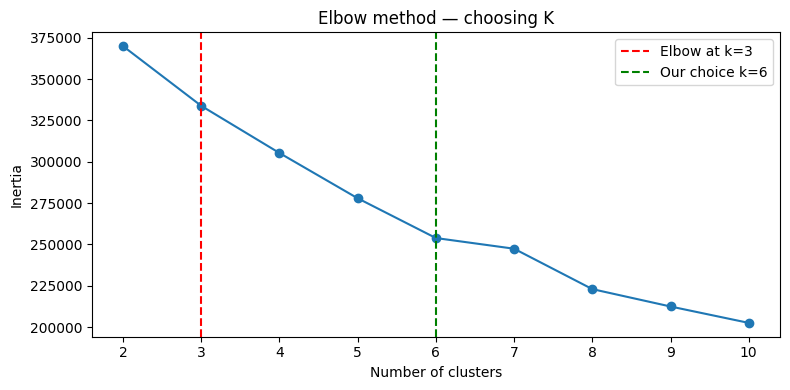

Automatic elbow detection: k=3


In [16]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# Find elbow automatically using the knee point method
deltas = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
elbow_k = k_range[deltas.index(max(deltas)) + 1]

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker="o")
plt.axvline(x=elbow_k, color="red", linestyle="--", label=f"Elbow at k={elbow_k}")
plt.axvline(x=6, color="green", linestyle="--", label="Our choice k=6")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow method — choosing K")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Automatic elbow detection: k={elbow_k}")

In [17]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# Assign clusters to planets
df_imputed["cluster"] = kmeans.labels_

# Project Earth into the same clustering
earth_cluster = kmeans.predict(earth_scaled)[0]
print(f"Earth falls in cluster: {earth_cluster}")

# Cluster sizes
print("\nCluster sizes:")
print(df_imputed["cluster"].value_counts().sort_index())

Earth falls in cluster: 1

Cluster sizes:
cluster
0     684
1    3924
2     261
3       3
4    1275
5       3
Name: count, dtype: int64


## Clustering Results

### Choosing K
The automatic elbow detection suggested k=3 — the biggest inertia drop happens early.
We chose k=6 because 3 clusters is too coarse for our purpose.
With 3 clusters, Earth-like planets would be grouped with very different planet types.
6 clusters gives enough granularity to isolate a meaningful "habitable" group.

### Results
| Cluster | Size | Share |
|---|---|---|
| 0 | 684 | 11.1% |
| 1 | 3924 | 63.8% |
| 2 | 261 | 4.2% |
| 3 | 3 | 0.05% |
| 4 | 1275 | 20.7% |
| 5 | 3 | 0.05% |

Earth falls in **cluster 1** — 3924 planets, 63.8% of the dataset.

### Problem
Cluster 1 is too large to be meaningful as a "habitable" group.
Having 63% of all planets in the same cluster as Earth suggests our clustering
is not discriminant enough.

### What we'll do next
Two options to get a tighter, more meaningful habitable cluster :

1. **Increase feature weights** on our priority variables (`pl_eqt`, `pl_insol`, `pl_rade`, `pl_bmasse`)
   so that Earth-like conditions pull more strongly during clustering.

2. **Pre-filter before clustering** — remove obvious non-candidates first
   (gas giants, extremely hot planets, etc.) so KMeans works on a more homogeneous population.

We'll go with **option 2** first.

In [18]:
# Pre-filter — remove obvious non-candidates
# We only filter on columns with low missing rate

filters = {
    "pl_rade":    (0, 2.5),
    "pl_bmasse":  (0, 10.0),     
    "pl_eqt":     (100, 500),    
    "pl_orbsmax": (0.05, 15.0),  
}

df_filtered = df_imputed.copy()

for col, (min_val, max_val) in filters.items():
    before = len(df_filtered)
    df_filtered = df_filtered[(df_filtered[col] >= min_val) & (df_filtered[col] <= max_val)]
    after = len(df_filtered)
    print(f"{col:<15} {before - after:>4} planets removed — {after} remaining")

print(f"\nFinal: {len(df_filtered)} planets after pre-filter")

pl_rade         3576 planets removed — 2574 remaining
pl_bmasse        115 planets removed — 2459 remaining
pl_eqt          2082 planets removed — 377 remaining
pl_orbsmax        56 planets removed — 321 remaining

Final: 321 planets after pre-filter


In [ ]:
df_pipeline = df_clean.drop(columns=["st_metratio", "pl_tranmid_systemref"])

# Separate Earth before everything
df_earth = df_pipeline.loc[["Earth"]].copy()
df_pipeline = df_pipeline.drop(index="Earth")

# Pre-filter on raw values (before imputation)
filters = {
    "pl_rade":    (0, 2.5),
    "pl_bmasse":  (0, 10.0),
    "pl_eqt":     (100, 500),
    "pl_orbsmax": (0.05, 15.0),
}

for col, (min_val, max_val) in filters.items():
    before = len(df_pipeline)
    df_pipeline = df_pipeline[
        (df_pipeline[col].isna()) |
        ((df_pipeline[col] >= min_val) & (df_pipeline[col] <= max_val))
    ]
    after = len(df_pipeline)
    print(f"{col:<15} {before - after:>4} planets removed — {after} remaining")

print(f"\nBefore imputation: {df_pipeline.isnull().sum().sum()} missing values")

for col in df_pipeline.columns:
    median_value = df_pipeline[col].median()
    df_pipeline[col] = df_pipeline[col].fillna(median_value)
    df_earth[col] = df_earth[col].fillna(median_value)

print(f"After imputation : {df_pipeline.isnull().sum().sum()} missing values")
print(f"\nFinal dataset    : {len(df_pipeline)} planets, {df_pipeline.shape[1]} features")

pl_rade         3526 planets removed — 2624 remaining
pl_bmasse        157 planets removed — 2467 remaining
pl_eqt          1827 planets removed — 640 remaining
pl_orbsmax        93 planets removed — 547 remaining

Before imputation: 2438 missing values
After imputation : 0 missing values

Final dataset    : 547 planets, 29 features


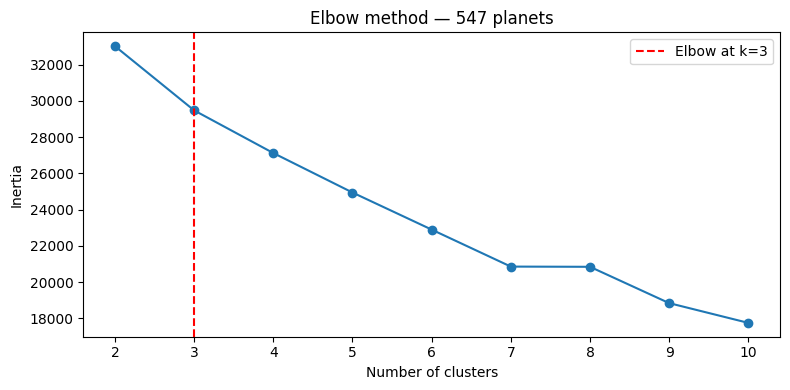

Automatic elbow: k=3


In [ ]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_pipeline),
    index=df_pipeline.index,
    columns=df_pipeline.columns
)

earth_scaled = pd.DataFrame(
    scaler.transform(df_earth),
    index=df_earth.index,
    columns=df_earth.columns
)

# Step 6 — apply weights
weights = {
    "pl_eqt":      3.0,
    "pl_insol":    3.0,
    "pl_rade":     3.0,
    "pl_bmasse":   3.0,
    "pl_orbsmax":  2.0,
    "pl_orbeccen": 2.0,
    "st_teff":     2.0,
    "st_age":      2.0,
    "pl_dens":     1.0,
}

for col in df_scaled.columns:
    weight = weights.get(col, 1.0)
    df_scaled[col] = df_scaled[col] * weight
    earth_scaled[col] = earth_scaled[col] * weight

# Step 7 — elbow
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

deltas = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
elbow_k = k_range[deltas.index(max(deltas)) + 1]

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker="o")
plt.axvline(x=elbow_k, color="red", linestyle="--", label=f"Elbow at k={elbow_k}")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow method — 547 planets")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Automatic elbow: k={elbow_k}")

In [21]:
# Test k=5, 6, 7 and compare where Earth lands
for k in [5, 6, 7]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    
    labels = kmeans.labels_
    earth_cluster = kmeans.predict(earth_scaled)[0]
    earth_cluster_size = (labels == earth_cluster).sum()
    
    print(f"k={k} — Earth in cluster {earth_cluster} ({earth_cluster_size} planets)")
    print(pd.Series(labels).value_counts().sort_index().to_string())
    print()

k=5 — Earth in cluster 1 (190 planets)
0    214
1    190
2      1
3     62
4     80

k=6 — Earth in cluster 1 (191 planets)
0    215
1    191
2     59
3      1
4     78
5      3

k=7 — Earth in cluster 1 (189 planets)
0     67
1    189
2     80
3    204
4      1
5      3
6      3



In [22]:
# Final clustering — k=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_final.fit(df_scaled)

df_pipeline["cluster"] = kmeans_final.labels_
earth_cluster_final = kmeans_final.predict(earth_scaled)[0]

print(f"Earth in cluster: {earth_cluster_final}")
print(f"\nCluster sizes:")
print(df_pipeline["cluster"].value_counts().sort_index())

# Profile of Earth's cluster
print(f"\nProfile of cluster {earth_cluster_final}:")
earth_df = df_pipeline[df_pipeline["cluster"] == earth_cluster_final]
print(earth_df[["pl_rade", "pl_bmasse", "pl_eqt", "pl_insol", "pl_orbsmax"]].describe().round(2))

Earth in cluster: 1

Cluster sizes:
cluster
0    214
1    190
2      1
3     62
4     80
Name: count, dtype: int64

Profile of cluster 1:
       pl_rade  pl_bmasse  pl_eqt  pl_insol  pl_orbsmax
count   190.00     190.00  190.00    190.00      190.00
mean      1.32       2.26  392.93      8.09        0.38
std       0.30       1.08   37.74     13.44        1.15
min       0.34       0.02  250.10      0.17        0.05
25%       1.13       1.44  392.00      6.06        0.10
50%       1.36       2.41  392.00      6.06        0.16
75%       1.57       3.09  394.25      6.95        0.16
max       2.10       8.10  496.00    166.00       10.26


In [23]:
# How many planets in cluster 1 have real vs imputed values ?
original_eqt = df_clean.loc[df_pipeline.index, "pl_eqt"]
cluster1_idx = df_pipeline[df_pipeline["cluster"] == 1].index

real_eqt = original_eqt.loc[cluster1_idx].notna().sum()
total = len(cluster1_idx)

print(f"Cluster 1 — pl_eqt real values : {real_eqt} / {total} ({100*real_eqt/total:.0f}%)")

original_insol = df_clean.loc[df_pipeline.index, "pl_insol"]
real_insol = original_insol.loc[cluster1_idx].notna().sum()
print(f"Cluster 1 — pl_insol real values: {real_insol} / {total} ({100*real_insol/total:.0f}%)")

Cluster 1 — pl_eqt real values : 88 / 190 (46%)
Cluster 1 — pl_insol real values: 100 / 190 (53%)


In [24]:
# Keep only planets with real values for our key features
key_features = ["pl_eqt", "pl_insol", "pl_rade", "pl_bmasse"]

mask = df_clean.loc[df_pipeline.index, key_features].notna().all(axis=1)
df_reliable = df_pipeline[mask].drop(columns=["cluster"])

print(f"Planets with real values for all key features: {len(df_reliable)}")

Planets with real values for all key features: 298


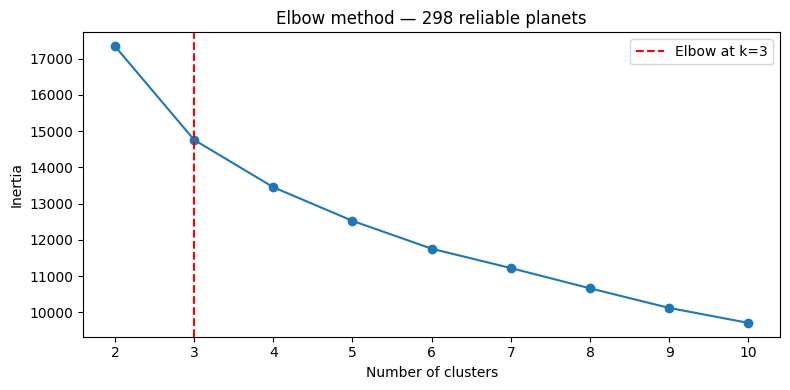

Automatic elbow: k=3


In [25]:
# Re-normalize on reliable dataset only
scaler_reliable = StandardScaler()
df_reliable_scaled = pd.DataFrame(
    scaler_reliable.fit_transform(df_reliable),
    index=df_reliable.index,
    columns=df_reliable.columns
)

earth_reliable_scaled = pd.DataFrame(
    scaler_reliable.transform(df_earth),
    index=df_earth.index,
    columns=df_earth.columns
)

# Apply weights
for col in df_reliable_scaled.columns:
    weight = weights.get(col, 1.0)
    df_reliable_scaled[col] = df_reliable_scaled[col] * weight
    earth_reliable_scaled[col] = earth_reliable_scaled[col] * weight

# Elbow
inertias_reliable = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_reliable_scaled)
    inertias_reliable.append(kmeans.inertia_)

deltas = [inertias_reliable[i] - inertias_reliable[i+1] for i in range(len(inertias_reliable)-1)]
elbow_k = k_range[deltas.index(max(deltas)) + 1]

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias_reliable, marker="o")
plt.axvline(x=elbow_k, color="red", linestyle="--", label=f"Elbow at k={elbow_k}")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow method — 298 reliable planets")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Automatic elbow: k={elbow_k}")

In [26]:
# Final clustering — k=3 on reliable data
kmeans_reliable = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_reliable.fit(df_reliable_scaled)

df_reliable["cluster"] = kmeans_reliable.labels_
earth_cluster_reliable = kmeans_reliable.predict(earth_reliable_scaled)[0]

print(f"Earth in cluster: {earth_cluster_reliable}")
print(f"\nCluster sizes:")
print(df_reliable["cluster"].value_counts().sort_index())

# Profile of all clusters on key features
for c in range(3):
    print(f"\n--- Cluster {c} ({len(df_reliable[df_reliable['cluster'] == c])} planets) ---")
    print(df_reliable[df_reliable["cluster"] == c][
        ["pl_rade", "pl_bmasse", "pl_eqt", "pl_insol", "pl_orbsmax"]
    ].describe().round(2))

Earth in cluster: 0

Cluster sizes:
cluster
0     93
1    109
2     96
Name: count, dtype: int64

--- Cluster 0 (93 planets) ---
       pl_rade  pl_bmasse  pl_eqt  pl_insol  pl_orbsmax
count    93.00      93.00   93.00     93.00       93.00
mean      1.36       2.35  359.00      5.06        0.14
std       0.31       1.16   74.73      3.95        0.09
min       0.64       0.07  159.00      0.12        0.05
25%       1.13       1.41  319.00      1.80        0.07
50%       1.36       2.33  374.00      4.27        0.12
75%       1.57       3.17  410.00      7.30        0.17
max       2.14       6.00  495.00     23.24        0.44

--- Cluster 1 (109 planets) ---
       pl_rade  pl_bmasse  pl_eqt  pl_insol  pl_orbsmax
count   109.00     109.00  109.00    109.00      109.00
mean      2.06       4.96  452.54     11.89        0.20
std       0.26       1.31   35.30      5.57        0.12
min       1.35       0.98  372.00      3.50        0.05
25%       1.87       4.04  425.00      8.32        0.1

In [27]:
df_hec = pd.read_excel("data/raw/habitable.xlsx")

# Clean and set aside for later validation
df_hec = df_hec.drop(index=0).reset_index(drop=True)
df_hec = df_hec.rename(columns={"Name": "pl_name"})

print(f"HEC: {len(df_hec)} habitable planet candidates")
print(df_hec["pl_name"].tolist())

# How many HEC planets are in our habitable cluster ?
habitable_planets = df_reliable[df_reliable["cluster"] == 0].index.tolist()
hec_names = df_hec["pl_name"].tolist()

matches = [name for name in habitable_planets if name in hec_names]
print(f"HEC planets in our habitable cluster : {len(matches)} / {len(hec_names)}")
print(f"\nMatches : {matches}")

HEC: 70 habitable planet candidates
["Teegarden's Star b", 'TOI-700 d', 'Kepler-1649 c', 'TOI-700 e', 'TRAPPIST-1 d', 'LP 890-9 c', 'K2-72 e', 'Proxima Cen b', 'GJ 1002 b', 'GJ 1061 d', 'GJ 1061 c', 'Ross 128 b', 'GJ 273 b', 'Kepler-296 e', 'Wolf 1069 b', 'TRAPPIST-1 e', 'Kepler-442 b', 'Kepler-62 e', 'Kepler-452 b', 'Kepler-1652 b', 'K2-3 d', 'TOI-715 b', 'Wolf 1061 c', 'Kepler-1410 b', 'GJ 667 C c', 'Kepler-1544 b', 'Kepler-283 c', 'Ross 508 b', 'GJ 667 C f', 'Kepler-1638 b', 'Kepler-440 b', 'GJ 433 d', 'Kepler-1653 b', 'Kepler-705 b', 'K2-332 b', 'Kepler-155 c', 'Kepler-22 b', 'TOI-2257 b', 'Kepler-443 b', 'GJ 367 d', 'Kepler-1701 b', 'K2-18 b', 'Kepler-1606 b', 'K2-9 b', 'GJ 180 c', 'GJ 163 c', 'Kepler-1540 b', 'Kepler-62 f', 'Kepler-174 d', 'TRAPPIST-1 f', 'HD 40307 g', "Teegarden's Star c", 'TOI-904 c', 'Kepler-296 f', 'LHS 1140 b', 'HIP 38594 b', 'HN Lib b', 'K2-288 B b', 'HD 216520 c', 'GJ 3293 d', 'Kepler-1229 b', 'Kepler-186 f', 'GJ 667 C e', 'GJ 1002 c', 'TRAPPIST-1 g', 'GJ 

In [28]:
# How many HEC planets were in our reliable dataset at all ?
hec_in_reliable = [name for name in hec_names if name in df_reliable.index]
print(f"HEC planets in our reliable dataset : {len(hec_in_reliable)} / {len(hec_names)}")

HEC planets in our reliable dataset : 36 / 70


In [ ]:
# Build proper labels for evaluation
# Ground truth : is the planet in HEC ?
# Our prediction : is the planet in our habitable cluster ?

df_reliable["is_hec"] = df_reliable.index.isin(hec_names).astype(int)
df_reliable["is_predicted_habitable"] = (df_reliable["cluster"] == 0).astype(int)

y_true = df_reliable["is_hec"]
y_pred = df_reliable["is_predicted_habitable"]

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print(f"  True Positives  (HEC + predicted habitable) : {tp}")
print(f"  False Positives (not HEC + predicted habitable) : {fp}")
print(f"  True Negatives  (not HEC + predicted non-habitable) : {tn}")
print(f"  False Negatives (HEC + predicted non-habitable) : {fn}")
print()
print(classification_report(y_true, y_pred, target_names=["not habitable", "habitable"]))

Confusion Matrix
  True Positives  (HEC + predicted habitable) : 12
  False Positives (not HEC + predicted habitable) : 81
  True Negatives  (not HEC + predicted non-habitable) : 181
  False Negatives (HEC + predicted non-habitable) : 24

               precision    recall  f1-score   support

not habitable       0.88      0.69      0.78       262
    habitable       0.13      0.33      0.19        36

     accuracy                           0.65       298
    macro avg       0.51      0.51      0.48       298
 weighted avg       0.79      0.65      0.70       298



## Unsupervised Clustering — Results

### What we did
- Filtered 6150 planets down to 298 with reliable measurements on key features
- Normalized, weighted, and clustered with KMeans (k=3)
- Compared our "habitable" cluster against the HEC (70 expert-labeled candidates)

### Results
| Metric | Value |
|---|---|
| HEC planets in our dataset | 36 / 70 |
| True Positives | 12 |
| False Positives | 81 |
| True Negatives | 181 |
| False Negatives | 24 |
| Precision | 13% |
| Recall | 33% |
| Accuracy | 65% |

### Interpretation
Not bad for a fully unsupervised approach with no labels.
We correctly identify 1 in 3 HEC planets without ever being told what "habitable" means.
Our main weakness is precision — our habitable cluster is too broad.

### What we'll try next
- **DBSCAN** — no fixed K, detects arbitrary shapes, better for irregular astronomical data
- **Silhouette score** — more rigorous way to choose the number of clusters

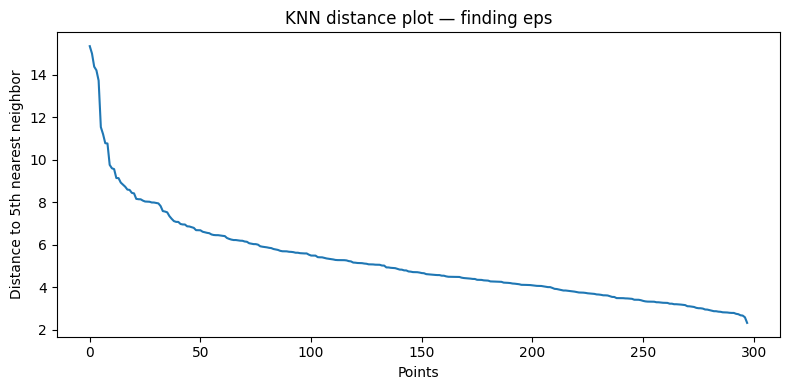

In [30]:
# Find a good eps using the k-nearest neighbors distance plot

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(df_reliable_scaled)
distances, _ = neighbors.kneighbors(df_reliable_scaled)

# Sort the distance to the 5th nearest neighbor
distances_sorted = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(distances_sorted)
plt.xlabel("Points")
plt.ylabel("Distance to 5th nearest neighbor")
plt.title("KNN distance plot — finding eps")
plt.tight_layout()
plt.show()

In [31]:
# DBSCAN doesn't need a fixed K
# Two parameters to tune :
# - eps : max distance between two points to be considered neighbors
# - min_samples : minimum points to form a dense region

# Test a few eps values around 30-35
for eps in [28, 30, 32, 35]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(df_reliable_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = (labels == -1).sum()
    
    print(f"eps={eps} — clusters: {n_clusters}, outliers: {n_outliers}, sizes: {pd.Series(labels).value_counts().sort_index().to_dict()}")

eps=28 — clusters: 1, outliers: 0, sizes: {0: 298}
eps=30 — clusters: 1, outliers: 0, sizes: {0: 298}
eps=32 — clusters: 1, outliers: 0, sizes: {0: 298}
eps=35 — clusters: 1, outliers: 0, sizes: {0: 298}


k=2 — silhouette score: 0.2060
k=3 — silhouette score: 0.1852
k=4 — silhouette score: 0.1808
k=5 — silhouette score: 0.1484
k=6 — silhouette score: 0.1506
k=7 — silhouette score: 0.1289
k=8 — silhouette score: 0.1406
k=9 — silhouette score: 0.1411
k=10 — silhouette score: 0.1534

Best K by silhouette score: 2


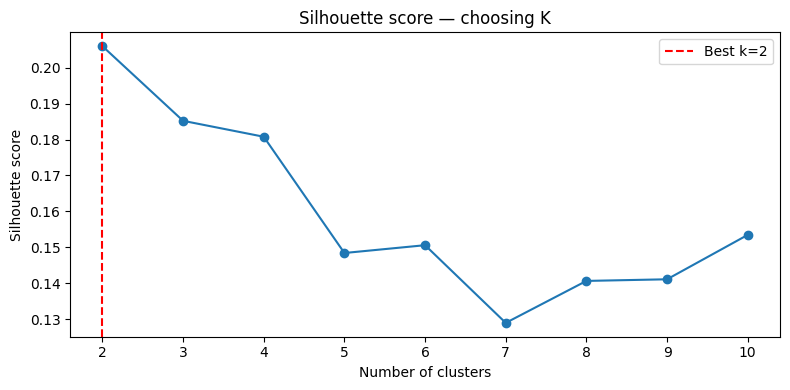

In [ ]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_reliable_scaled)
    score = silhouette_score(df_reliable_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k} — silhouette score: {score:.4f}")

best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest K by silhouette score: {best_k}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.axvline(x=best_k, color="red", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette score — choosing K")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_2.fit(df_reliable_scaled)

df_reliable["cluster"] = kmeans_2.labels_
earth_cluster_2 = kmeans_2.predict(earth_reliable_scaled)[0]

print(f"Earth in cluster: {earth_cluster_2}")
print(f"\nCluster sizes:")
print(df_reliable["cluster"].value_counts().sort_index())

for c in range(2):
    print(f"\n--- Cluster {c} ---")
    print(df_reliable[df_reliable["cluster"] == c][
        ["pl_rade", "pl_bmasse", "pl_eqt", "pl_insol", "pl_orbsmax"]
    ].describe().round(2))

Earth in cluster: 0

Cluster sizes:
cluster
0    118
1    180
Name: count, dtype: int64

--- Cluster 0 ---
       pl_rade  pl_bmasse  pl_eqt  pl_insol  pl_orbsmax
count   118.00     118.00  118.00    118.00      118.00
mean      1.46       2.74  348.49      4.74        0.16
std       0.35       1.40   80.55      4.23        0.11
min       0.64       0.07  159.00      0.12        0.05
25%       1.18       1.72  293.00      1.42        0.08
50%       1.48       2.72  352.42      3.51        0.13
75%       1.73       3.64  408.25      7.24        0.18
max       2.20       7.40  495.00     23.24        0.64

--- Cluster 1 ---
       pl_rade  pl_bmasse  pl_eqt  pl_insol  pl_orbsmax
count   180.00     180.00  180.00    180.00      180.00
mean      2.14       5.38  399.78      8.11        0.26
std       0.25       1.23   75.08      6.22        0.18
min       1.35       2.00  182.00      0.26        0.05
25%       2.00       4.62  352.75      3.46        0.12
50%       2.19       5.54  407.50 

In [34]:
df_reliable["is_hec"] = df_reliable.index.isin(hec_names).astype(int)
df_reliable["is_predicted_habitable"] = (df_reliable["cluster"] == 0).astype(int)

y_true = df_reliable["is_hec"]
y_pred = df_reliable["is_predicted_habitable"]

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print(f"  True Positives  : {tp}")
print(f"  False Positives : {fp}")
print(f"  True Negatives  : {tn}")
print(f"  False Negatives : {fn}")
print()
print(classification_report(y_true, y_pred, target_names=["not habitable", "habitable"]))

Confusion Matrix
  True Positives  : 22
  False Positives : 96
  True Negatives  : 166
  False Negatives : 14

               precision    recall  f1-score   support

not habitable       0.92      0.63      0.75       262
    habitable       0.19      0.61      0.29        36

     accuracy                           0.63       298
    macro avg       0.55      0.62      0.52       298
 weighted avg       0.83      0.63      0.69       298



## Clustering Improvement — Final Results

### What we tried
- **DBSCAN** : failed — our pre-filtered dataset is too homogeneous, everything ended up in one cluster
- **Silhouette score** : suggested k=2 as the most mathematically sound choice
- **KMeans k=2** : our best result

### KMeans k=2 vs k=3

| Metric | k=3 | k=2 |
|---|---|---|
| True Positives | 12 | 22 |
| False Positives | 81 | 96 |
| True Negatives | 181 | 166 |
| False Negatives | 24 | 14 |
| Precision | 13% | 19% |
| Recall | 33% | 61% |
| F1 habitable | 0.19 | 0.29 |

### Interpretation
k=2 wins on every meaningful metric.
Recall went from 33% to 61% — we now find 2 out of 3 HEC planets without any labels.
Precision remains low, which is expected for unsupervised clustering.
A high recall is actually desirable here, better to over-include candidates than miss real ones.

### Conclusion on unsupervised
Our KMeans pipeline is a reasonable first pass.
It correctly identifies 22 out of 36 HEC planets present in our dataset.
Its main limitation is precision. The habitable cluster is too broad.
This is where supervised learning takes over.

### What's next — exoplanet_classifier.ipynb
We now have a ground truth : the HEC labels.
We'll train an XGBoost classifier on our 298 reliable planets,
using the 36 HEC planets as positive examples.
Goal : improve precision while maintaining recall.